# In this problem, you will generate simulated data, and then perform PCA and K-means clustering on the data.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from IPython.display import display


np.random.seed(34)

## (a) Generate a simulated data set with 20 observations in each of three classes (i.e. 60 observations total), and 50 variables. Hint: There are a number of functions in Python that you can use to generate data. One example is the normal() method of the random() function in numpy; the uniform() method is another option. Be sure to add a mean shift to the observations in each class so that there are three distinct classes.

In [3]:
n_observations = 60
n_variables = 50
n_classes = 3
observations_per_class = n_observations // n_classes


data = np.zeros((n_observations, n_variables))
labels = np.zeros(n_observations)

for i in range(n_classes):
    start_index = i * observations_per_class
    end_index = (i + 1) * observations_per_class

    mean_shift = i * 4 # 移動大一點確保三個分類的點會分開
    data[start_index:end_index, :] = np.random.normal(loc=mean_shift, scale=1, size=(observations_per_class, n_variables))
    labels[start_index:end_index] = i

print("Shape of data:", data.shape)
print("Shape of labels:", labels.shape)

Shape of data: (60, 50)
Shape of labels: (60,)


## (b) Perform PCA on the 60 observations and plot the first two principal component score vectors. Use a diferent color to indicate the observations in each of the three classes. If the three classes appear separated in this plot, then continue on to part (c). If not, then return to part (a) and modify the simulation so that there is greater separation between the three classes. Do not continue to part (c) until the three classes show at least some separation in the frst two principal component score vectors.

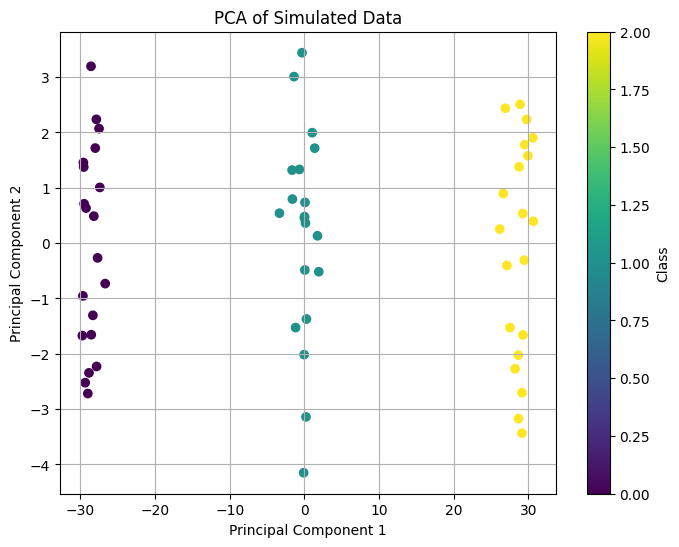

In [4]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(data)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(principal_components[:, 0], principal_components[:, 1], c=labels, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Simulated Data')
plt.colorbar(scatter, label='Class')
plt.grid(True)
plt.show()

## (c) Perform K-means clustering of the observations with K = 3. How well do the clusters that you obtained in K-means clustering compare to the true class labels?

### Result
After performing K-Means clustering, I found that although it successfully divided the data into three clusters and the overall clustering structure is similar to the original three classes, the actual cluster labels do not match the original class labels. For example, in this particular result, observations with a class label of 0 were assigned to cluster 0, class label 1 to cluster 2, and class label 2 to cluster 1.

This mismatch occurs because K-Means does not take the original class labels into account when performing clustering. The cluster label assignments are arbitrary and may be ordered randomly.

### From this, we can conclude:
- K-Means successfully clustered the data based on its features, and the resulting clusters align well with the original class structure.
- The cluster labels are assigned in a different order than the original class labels.

Comparison of True Class Labels and K-means Cluster Labels:


Cluster Label,0,1,2
Origin Label,,,
0.0,20,0,0
1.0,0,0,20
2.0,0,20,0


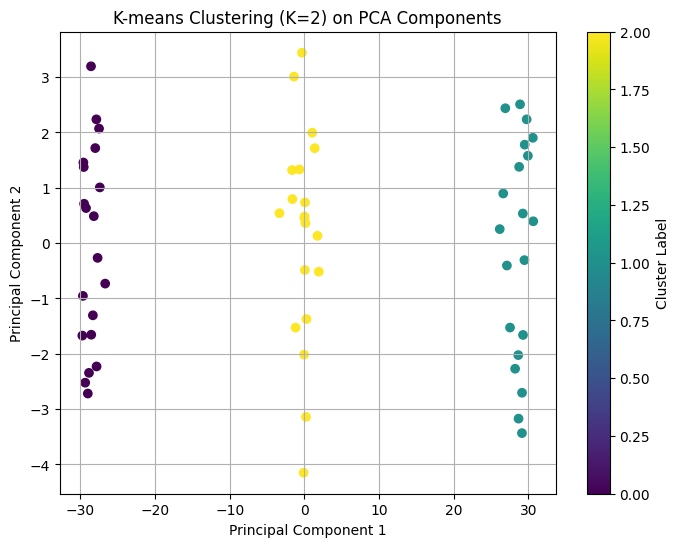

In [5]:
kmeans = KMeans(n_clusters=3, random_state=34, n_init=10)
kmeans.fit(data)
cluster_labels = kmeans.labels_

comparison = pd.crosstab(pd.Series(labels, name='Origin Label'), pd.Series(cluster_labels, name='Cluster Label'))

print("Comparison of True Class Labels and K-means Cluster Labels:")
display(comparison)

# 嘗試使用 PCA 視覺化 K-Means 結果
plt.figure(figsize=(8, 6))
scatter = plt.scatter(principal_components[:, 0], principal_components[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-means Clustering (K=2) on PCA Components')
plt.colorbar(scatter, label='Cluster Label')
plt.grid(True)
plt.show()

## (d) Perform K-means clustering with K = 2. Describe your results.

### Result
When the number of clusters is set to 2, the data is cleanly separated into two groups. All observations originally labeled as class 1 are grouped together with those from class 0 into cluster 0, while the observations with the original label 2 remain in cluster 1 (original third cluster).


Comparison of True Class Labels and K-means Cluster Labels (K=2):


Cluster Label,0,1
Origin Label,,
0.0,20,0
1.0,20,0
2.0,0,20


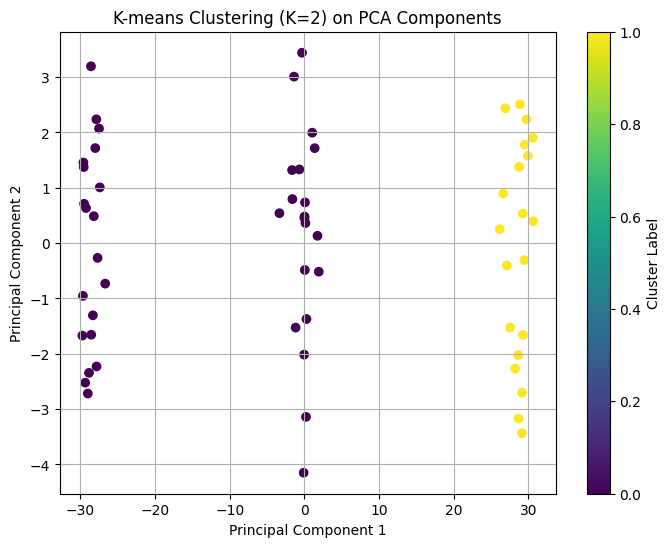

In [6]:
# n_clusters 設為 2
kmeans = KMeans(n_clusters=2, random_state=34, n_init=10)
kmeans.fit(data)
cluster_labels_k2 = kmeans.labels_

comparison_k2 = pd.crosstab(pd.Series(labels, name='Origin Label'), pd.Series(cluster_labels_k2, name='Cluster Label'))

print("Comparison of True Class Labels and K-means Cluster Labels (K=2):")
display(comparison_k2)

# 嘗試使用 PCA 視覺化 K-Means 結果
plt.figure(figsize=(8, 6))
scatter = plt.scatter(principal_components[:, 0], principal_components[:, 1], c=cluster_labels_k2, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-means Clustering (K=2) on PCA Components')
plt.colorbar(scatter, label='Cluster Label')
plt.grid(True)
plt.show()

## (e)  Now perform K-means clustering with K = 4, and describe your results.

### Result
When the number of clusters is set to 4, we can observe that since the data was originally divided into only 3 main groups, a perfect separation is not achievable. As a result, two of the original groups still align well with two clusters (i.e., one original class corresponds to one cluster), while the third group (in this case, the middle group) is split across two different clusters.

It can be seen that the data spanning across the two clusters all originate from class 1. Both of these clusters appear to start from the edge of the class 1 region. Although there is some overlap between them, the data seems to form a continuous structure.

Additionally, the order of the cluster labels has once again changed.



Comparison of True Class Labels and K-means Cluster Labels (K=4):


Cluster Label,0,1,2,3
Origin Label,,,,
0.0,0,0,20,0
1.0,10,0,0,10
2.0,0,20,0,0


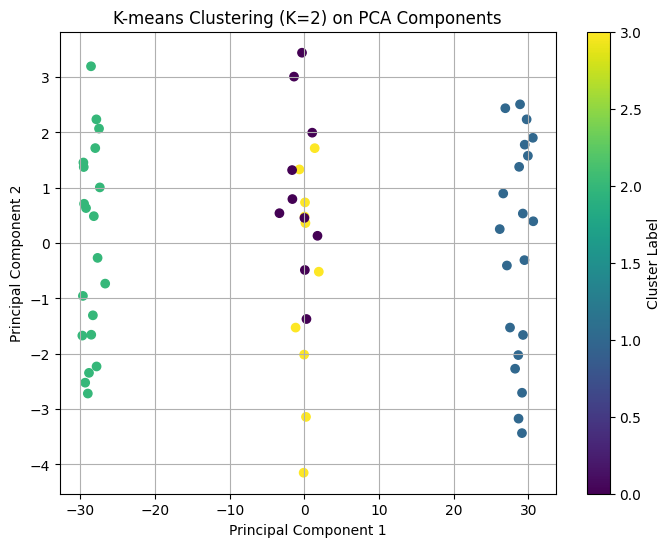

In [7]:
# n_clusters 設為 4
kmeans = KMeans(n_clusters=4, random_state=34, n_init=10)
kmeans.fit(data)
cluster_labels_k4 = kmeans.labels_

comparison_k4 = pd.crosstab(pd.Series(labels, name='Origin Label'), pd.Series(cluster_labels_k4, name='Cluster Label'))

print("Comparison of True Class Labels and K-means Cluster Labels (K=4):")
display(comparison_k4)

# 嘗試使用 PCA 視覺化 K-Means 結果
plt.figure(figsize=(8, 6))
scatter = plt.scatter(principal_components[:, 0], principal_components[:, 1], c=cluster_labels_k4, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-means Clustering (K=2) on PCA Components')
plt.colorbar(scatter, label='Cluster Label')
plt.grid(True)
plt.show()

## (f) Now perform K-means clustering with K = 3 on the frst two principal component score vectors, rather than on the raw data. That is, perform K-means clustering on the 60 × 2 matrix of which the frst column is the frst principal component score vector, and the second column is the second principal component score vector. Comment on the results.

### Result

After performing K-Means clustering on the PCA-reduced data, I found that the results were identical to those obtained from applying K-Means directly on the original data.

This could indicate several things:
- The dataset is relatively small, so the clustering structure is not significantly affected by dimensionality reduction.
- The original data is already well-separated and clean, making clustering straightforward.
- PCA successfully preserved the key information related to cluster separation within the origin data.

Cluster Label,0,1,2
Origin Label,,,
0.0,20,0,0
1.0,0,0,20
2.0,0,20,0


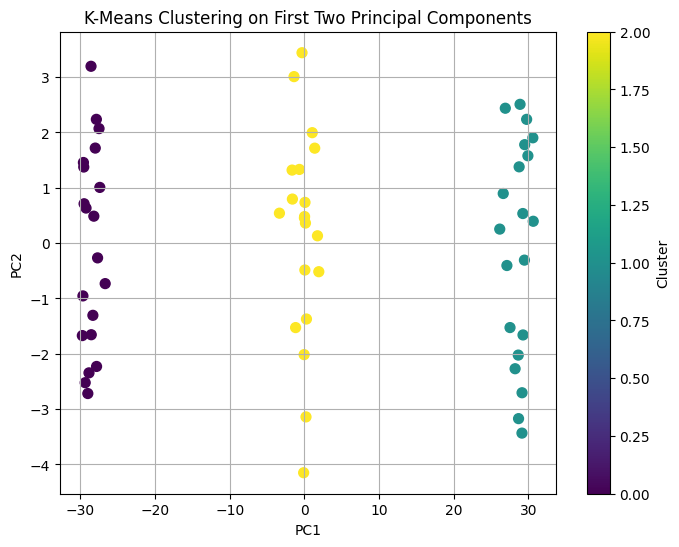

In [8]:
kmeans_pca = KMeans(n_clusters=3, random_state=34, n_init=10)
kmeans_pca.fit(principal_components)
cluster_labels_pca = kmeans_pca.labels_

comparison_pca = pd.crosstab(pd.Series(labels, name='Origin Label'), pd.Series(cluster_labels_pca, name='Cluster Label'))

display(comparison_pca)

plt.figure(figsize=(8,6))
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=cluster_labels_pca, cmap='viridis', s=50)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering on First Two Principal Components')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

## (g) Using the StandardScaler() estimator, perform K-means clus￾tering with K = 3 on the data after scaling each variable to have standard deviation one. How do these results compare to those obtained in (b)? Explain.

### Result
After scaling the data using StandardScaler and performing K-Means clustering with \( K=3 \), I found that the clustering results are the same as those obtained from clustering on the PCA-reduced data as well as directly on the original data.

This indicates that:
- Scaling balances the contribution of each feature, but the original features already had similar scales or clear cluster structure.
- Overall, the clustering structure is stable and consistent regardless of these preprocessing steps.

In [9]:
# 先將數據標準化再做 K-Means
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

kmeans_scaled = KMeans(n_clusters=3, random_state=34, n_init=10)
kmeans_scaled.fit(scaled_data)
cluster_labels_scaled = kmeans_scaled.labels_

comparison_scaled = pd.crosstab(pd.Series(labels, name='Origin Label'), pd.Series(cluster_labels_scaled, name='Cluster Label'))

display(comparison_scaled)

Cluster Label,0,1,2
Origin Label,,,
0.0,20,0,0
1.0,0,0,20
2.0,0,20,0
